In [56]:
# import os
import sys
import json
import numpy as np
import pandas as pd
import trackpy as tp
import matplotlib as mpl
import matplotlib.pyplot as plt
from skimage.measure import regionprops
import skimage.morphology as morph

sys.path.append("scripts/utils/")
from file_operations import *
from segmentation    import *
from Microscopes     import Holomonitor, Tomocube
from SegmentedCells  import SegmentedCells

data_path = "../../../../hdd_data/silja/Monolayers/"

In [66]:
dataset = "MDCK_20250904_B1-1"
config  = json.load(open(f"configs/{dataset}.json"))

### SET MICROSCOPE ###
if config['microscope'] == "holomonitor": microscope = Holomonitor()
elif config['microscope'] == "tomocube":  microscope = Tomocube()

im_areas  = load_label_images(f"{data_path}cell_labels/corrected/{dataset}/")
im_height = load_stack(f"{data_path}height_fields/raw/{dataset}/", config, param="height", data_type="field")



In [72]:
cell_props = SegmentedCells(f"cell_props.p")


# Compute region props of cells in all frames
cells = [regionprops(im_areas[i], im_height[i]) for i in range(len(im_areas))]

State loaded from cell_props.p.


In [68]:
# Prepare dataframe for tracking
Fcells = np.concatenate([[config['field']['fmin'] + frame for cell in cells[frame]] for frame in range(len(cells))])

Acells       = np.concatenate([[cell.area              for cell in cells] for cells in cells])
hcells       = np.concatenate([[cell.mean_intensity    for cell in cells] for cells in cells])
Lcells       = np.concatenate([[cell.label             for cell in cells] for cells in cells])

x_position   = np.concatenate([[cell.centroid_weighted[1] for cell in cells] for cells in cells])
y_position   = np.concatenate([[cell.centroid_weighted[0] for cell in cells] for cells in cells])

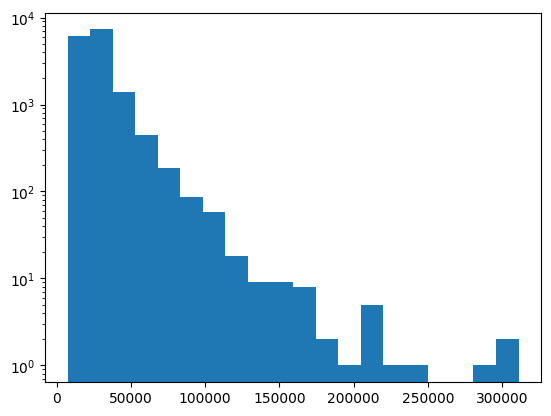

In [69]:
# plt.hist(Acells.ravel() * microscope.pix_to_um**2)
plt.hist(Acells.ravel(), bins=20)
plt.yscale("log")

Frame 40: 375 trajectories present.


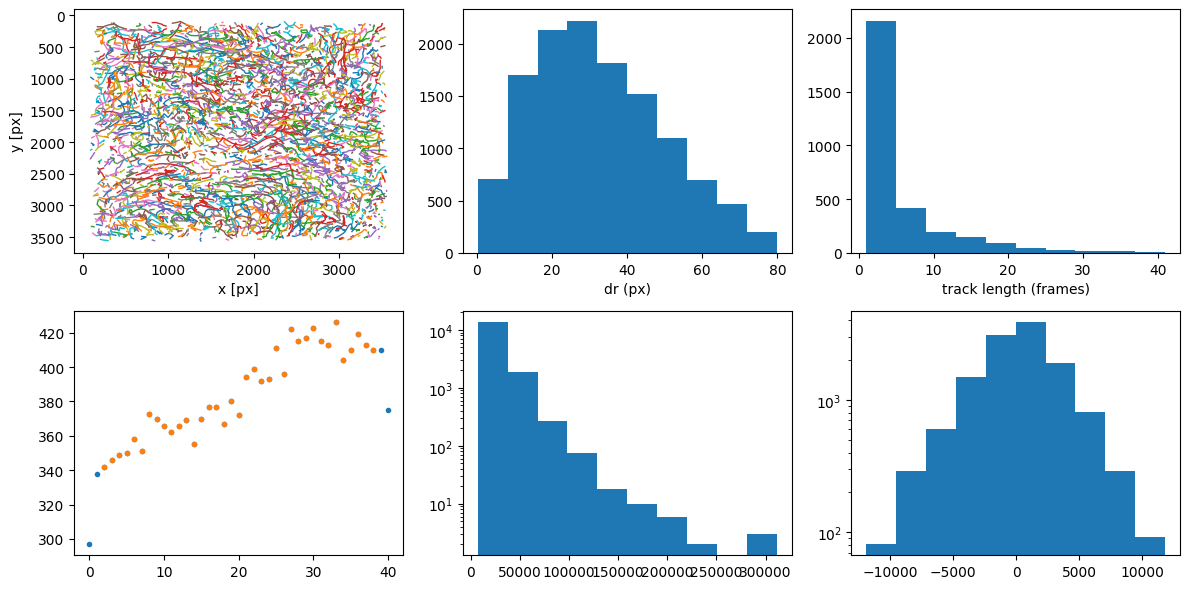

In [70]:

cells_df = pd.DataFrame({'x': x_position,
                         'y': y_position,
                         'area': Acells / microscope.A_scale,
                         'hmean': hcells,
                         'frame': Fcells})

# track cells
thres = 2
memory = 2
search_range = 80
tracks = tp.link(cells_df, search_range=search_range, memory=memory, pos_columns=['x', 'y', 'area']);
tracks = tp.filter_stubs(tracks, threshold=thres-2);

# compute displacement
dr = np.sqrt(tracks.groupby('particle')['x'].diff()**2 + tracks.groupby('particle')['y'].diff()**2).values
dA = tracks.groupby('particle')['area'].diff().values
Acells_tmp = tracks.area.values
#dh = tracks.groupby('particle')['hmean'].diff().values

# compute track length
track_length = [np.sum(tracks['particle'] == p_id) for p_id in np.unique(tracks['particle'])]

# compute number of cells
Ncells = [np.sum(tracks['frame'] == f) for f in np.unique(tracks.frame)]
frames = np.arange(thres, len(Ncells)-thres)

# plot result
fig, ax = plt.subplots(2,3, figsize=(12,6))
tp.plot_traj(tracks, ax=ax[0,0])
ax[0,1].hist(dr)
ax[0,2].hist(track_length);
ax[1,0].plot(Ncells, '.', label=thres)
ax[1,0].plot(frames, Ncells[thres:-thres], '.', label=thres)

ax[1,1].hist(Acells_tmp*microscope.A_scale)
ax[1,2].hist(dA*microscope.A_scale)

ax[1,1].set(yscale='log')
ax[1,2].set(yscale='log')

ax[0,1].set(xlabel="dr (px)", yscale="linear")
ax[0,2].set(xlabel="track length (frames)")
fig.tight_layout()


tracks = tracks[(tracks.frame >=(thres-1)) * (tracks.frame < np.max(tracks.frame)+1-(thres-1))]
cells_df['area'] *= microscope.A_scale

338


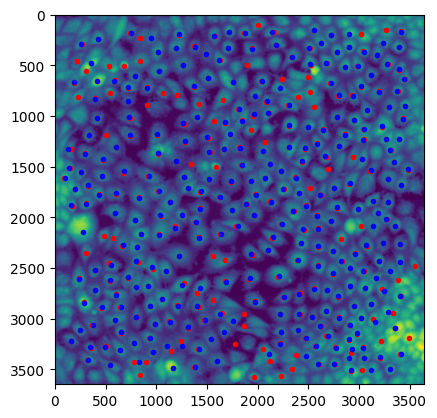

In [74]:
plt.imshow(im_height[config["cells"]["fmin"]])
plt.plot(tracks[tracks.frame == config["cells"]["fmin"]].x, tracks.y[tracks.frame == config["cells"]["fmin"]], 'r.')
plt.plot(cell_props.x[0] / microscope.pix_to_um, cell_props.y[0] / microscope.pix_to_um, 'b.')

print(len(tracks[tracks.frame == config["cells"]["fmin"]].x))

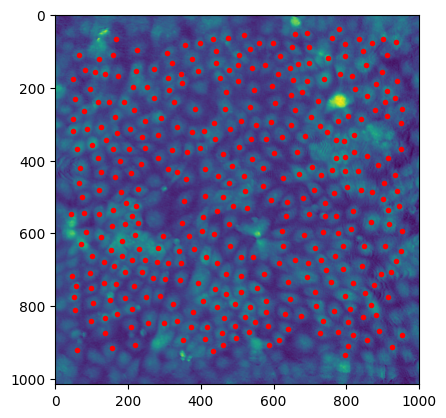

In [32]:
plt.imshow(im_height[config["cells"]["fmin"]])
plt.plot(tracks[tracks.frame == config["cells"]["fmin"]].x, tracks.y[tracks.frame == config["cells"]["fmin"]], 'r.')

In [21]:
# keep only frames where all cells can have tracks longer than thres
#tracks = tracks[(tracks.frame >=(thres-1)) * (tracks.frame < np.max(tracks.frame)+1-(thres-1))]

im_tracked = np.copy(im_areas)[5:-4]

for i in range(len(im_tracked)):
    labels = tracks[tracks.frame==5+i].label.values
    exclude = np.setdiff1d(np.unique(im_areas[5+i]), labels)

    for cell in exclude:
        mask = im_tracked[i] == cell
        im_tracked[i][mask] = 0

AttributeError: 'DataFrame' object has no attribute 'label'

In [ ]:
# keep only frames where all cells can have tracks longer than thres
im_tracked_new = np.copy(im_areas)[5:-4]

labels = tracks[tracks.frame==5].label.values
exclude = np.setdiff1d(np.unique(im_areas[5]), labels)

for cell in exclude:
        mask = im_tracked_new[i] == cell
        im_tracked_new[0][mask] == 0

for i in range(len(im_tracked_new)-1):
    labels = tracks[tracks.frame==5+i].label.values
    exclude = np.setdiff1d(np.unique(im_areas[5+i]), labels)

    for cell in exclude:
        mask = im_tracked_new[i] == cell
        im_tracked_new[i][mask] == im_tracked_new[i-1][mask]

In [96]:
labels = tracks[tracks.frame==5].label.values
exclude = np.setdiff1d(np.unique(im_areas[5]), labels)
im_tracked_new = np.copy(im_areas)[5:-4]

for cell in exclude:
    mask = im_tracked_new[i] == cell
    im_tracked_new[0][mask] == im_tracked_new[1][mask]

In [108]:
im_tracked[1][(im_tracked_new[0]==3)]

array([ 0,  0, 65, ...,  0,  0,  0], shape=(2849,))

In [269]:
np.save(f"data/experimental/processed/{dataset}/im_cell_areas_tracked.npy", im_tracked)

In [6]:
x_raw = tracks.pivot(index='frame', columns='particle', values='x').to_numpy()
y_raw = tracks.pivot(index='frame', columns='particle', values='y').to_numpy()
A_raw = tracks.pivot(index='frame', columns='particle', values='area').to_numpy() * pix_to_um[1]**2
h_raw = tracks.pivot(index='frame', columns='particle', values='hmean').to_numpy()
l_raw = tracks.pivot(index='frame', columns='particle', values='label').to_numpy()

x_raw = np.ma.masked_where(np.isnan(x_raw), x_raw)
y_raw = np.ma.masked_where(np.isnan(y_raw), y_raw)
A_raw = np.ma.masked_where(np.isnan(A_raw), A_raw)
h_raw = np.ma.masked_where(np.isnan(h_raw), h_raw)
l_raw = np.ma.masked_where(np.isnan(l_raw), l_raw)
V_raw = h_raw * A_raw

In [35]:
V1_arr = []
V2_arr = []
idx_arr = []

idx_division = []
idx_outlier = []
idx_split = []
idx_other = []
idx_normal = []

particle = []
std_arr = []

len_min = 4

i = 0
for p in np.unique(tracks['particle']):

    tmp_df = tracks[tracks.particle == p]
    if len(tmp_df) < 2:
        continue
    
    V = (tmp_df.hmean * tmp_df.area*a_scale).values

    V_median = np.ma.median(V)
    dV = np.diff(V)
    particle.append(p)

    idx = np.argmax(abs(dV))
    idx_arr.append(idx+1)

    V1 = np.ma.median(V[idx-10:idx])
    V2 = np.ma.median(V[idx:idx+10])
    V1_arr.append(V1)
    V2_arr.append(V2)
    
    if np.max(abs(dV)) / V_median > 0.4 and np.sum(V>0)>len_min:


        idx_split.append(i)

    elif np.sum(V>0)>len_min:
        idx_normal.append(i)
        
    i += 1

/home/silja/Documents/MDCK_QPI/mdck_venv/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/silja/Documents/MDCK_QPI/mdck_venv/lib/python3.12/site-packages/numpy/_core/_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [36]:
len(idx_normal), len(idx_split), len(idx_normal)+ len(idx_split)

(1315, 343, 1658)

In [37]:
#  for p in p_division:

#     # Create a mask to identify rows where the frame is greater than the split_frame
#     mask = (tracks.particle == p_particle[p]) * (tracks.frame > idx_arr[p]+5)

#     # Generate a new particle ID for rows after the split_frame
#     tracks.loc[mask, 'particle'] = tracks.loc[mask, 'particle'] + tracks['particle'].max()  # Update IDs



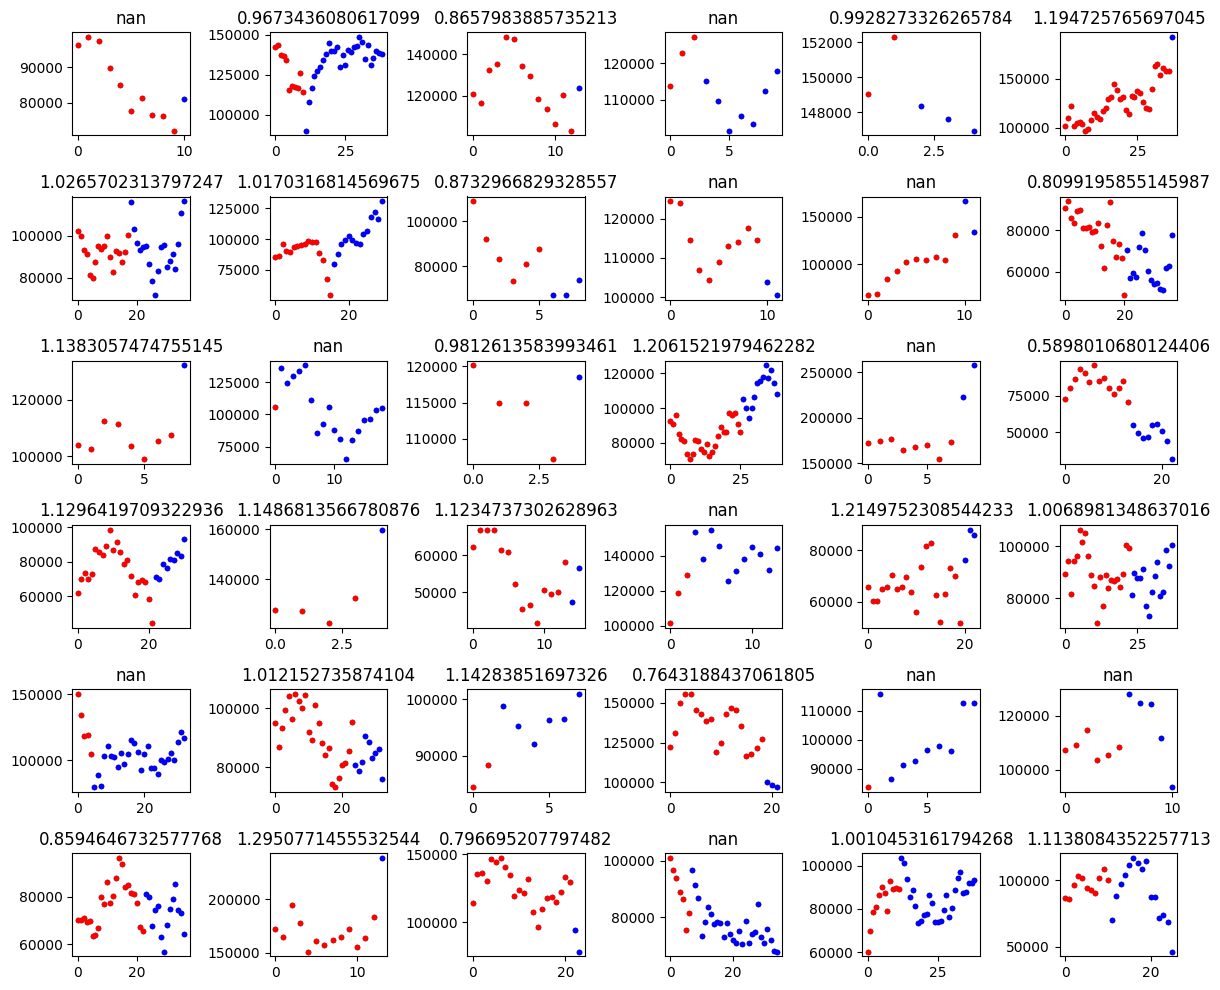

: 

In [ ]:
fig, ax = plt.subplots(6, 6, figsize=(12,10))

i = 0
for p, axes in zip(idx_normal[200:], ax.flatten()):

    tmp_df = tracks[tracks.particle == particle[p]]
    #V = tmp_df.area.values 
    #h = tmp_df.hmean.values
    V=(tmp_df.hmean * tmp_df.area*a_scale).values

    frame = np.arange(len(V))

    axes.plot(frame, V, 'k.', label=p)
    #axes.plot(frame, 100/h, 'c.', label=p)
    axes.plot(frame[:idx_arr[p]], V[:idx_arr[p]],'r.', label=p)
    axes.plot(frame[idx_arr[p]:], V[idx_arr[p]:],'b.', label=p)

    axes.set(title=f"{np.round((V2_arr[p])) / np.round(V1_arr[p])}")

    i+=1

fig.tight_layout()

In [ ]:
# start from longest track
# np.isnan
# if missing frame in the middle: 
# fill in missing frames x and y position as mean of before and after

x_raw = tracks.pivot(index='frame', columns='particle', values='x').to_numpy()
y_raw = tracks.pivot(index='frame', columns='particle', values='y').to_numpy()
A_raw = tracks.pivot(index='frame', columns='particle', values='area').to_numpy() * pix_to_um[1]**2
h_raw = tracks.pivot(index='frame', columns='particle', values='hmean').to_numpy()
p_raw = tracks.pivot(index='frame', columns='particle', values='particle').to_numpy()
f_raw = tracks.pivot(index='frame', columns='particle', values='frame').to_numpy()


In [480]:
mask = np.sum(A_raw > 0, axis=0) == 128
np.sort(np.sum(A_raw > 0, axis=0)), np.sum(mask)

(array([  1,   1,   1, ..., 129, 129, 129], shape=(1817,)), np.int64(1))

IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed

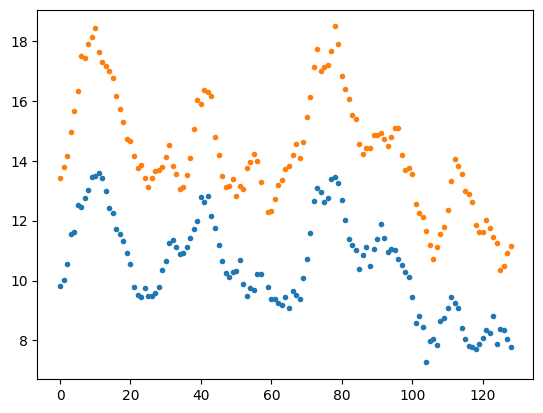

In [ ]:
plt.plot(A_raw[:,mask], '.')
plt.plot(60/h_raw[:,mask], '.')

In [504]:
f_raw[63-5,238], np.isnan(y_raw[:,238])

(np.float64(nan),
 array([False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False,  True, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, Fa